
# **Executive Summary** #

Municipal noise complaints place a direct burden on city resources, costing an average $150 in wasted capital per police dispatch. Yet the secondary economic impact, the decrease in taxable residential real estate value due to environmental noise, is largely unmeasured.

This project seeks to address two key questions:

1. How much do localized municipal noise dispatches financially reduce residential real estate values in Seattle's highest-dispatch police districts?

2. Can machine learning algorithms accurately predict Seattle home prices using only structural square footage and local environmental noise data?

### Summary of Data Preparation ###
Welcome to the second phase of the architecture: Statistical Modeling. To begin, I imported our core analytical libraries: Pandas for data manipulation, Seaborn for visualizations, and Scikit-Learn for our predictive algorithms.
<br><br>
This proof-of-concept was developed locally, combining datasets such as the Seattle Open Data API (911 logs) and King County Assessor bulk files (Sales, Residential, and Parcel data) using pandas. Geospatial joins identified properties in the top 5 police beats with the highest dispatch volumes.
<br><br>
I loaded the finalized master dataset we generated during the engineering phase, but to prepare for our Tableau deployment later, I needed to re-attach the raw Latitude and Longitude coordinates. I pulled in the original GIS coordinate file to merge it.
<br><br>
A critical architectural detail here: before executing the join, I coerced the 10-digit PIN column into a string data type on both dataframes. This is a vital programming step. If left as integers, Python can occasionally alter the structural integrity of massive ID numbers, causing merge failures. By forcing them to strings, I guaranteed an exact match.
<br><br>
Finally, I executed an inner join and dropped any rows missing Latitude or Longitude. For spatial analytics, a property without GPS coordinates is mathematically useless. This final scrub guarantees our modeling environment is geographically sound.


## ENVIRONMENT SETUP ##

In [170]:
import pandas as pd
import sklearn as sk
import numpy as np
import requests
import folium
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
import geopandas as gpd
from shapely.geometry import Point
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


#Suppress warnings
#warnings.filterwarnings('ignore')
print("Libraries setup successful")

Libraries setup successful


## Data Pipeline ##

In [171]:
print("Merging datasets")

#Load the Data
df_model = pd.read_csv('acoustic_urbanism_model_data.csv')
df_coords = pd.read_csv('coords.csv', low_memory=False)

#Convert created PIN to strings
df_model['PIN'] = df_model['PIN'].astype(str)
df_coords['PIN'] = df_coords['PIN'].astype(str)
print("Merge successful")

Merging datasets
Merge successful


In [172]:
#Merge prices with the coordinates
df_master = pd.merge(df_model, df_coords, on='PIN', how='inner').dropna(subset=['LAT', 'LON'])
df_master.head(1)

,PIN,DocumentDate,SalePrice,SqFtTotLiving,NbrLivingUnits,YrBuilt,CurrentZoning,beat,total_noise_dispatches,estimated_dispatch_waste_usd,...,MINOR,PRIMARY_ADDR,PRIMARY_ADDR_FILTER,SITETYPE_DESCRIPTION,Building,Unit,FUID,STATE_ABBR,x,y
0,3348401430,2026-03-10,475000,1300,1,1911,NR1,S3,189,28350,...,1430,1,E911:ONETOONE,Single Family,NaN,NaN,645603,WA,1.286406e+06,184981.873272



## Spatial Initialization (below) ##

With the raw coordinates merged into our dataset, I needed to initialize them as true spatial geometries. Instead of writing a complex loop, I utilized GeoPandas' native `points_from_xy` function.<br><br>
This method cleanly takes our Longitude and Latitude columns and instantly converts them into a formalized spatial geometry column, locked into the EPSG:4326 global GPS standard. This keeps our codebase readable and prepares the data for our spatial intersections.


In [173]:
#convert to Spatial GeoPandas DataFrame (The R-Tree Intersection)
gdf_properties = gpd.GeoDataFrame(
    df_master, 
    geometry=gpd.points_from_xy(df_master['LON'], df_master['LAT']), 
    crs="EPSG:4326"
)
gdf_properties.head(1)

,PIN,DocumentDate,SalePrice,SqFtTotLiving,NbrLivingUnits,YrBuilt,CurrentZoning,beat,total_noise_dispatches,estimated_dispatch_waste_usd,...,PRIMARY_ADDR,PRIMARY_ADDR_FILTER,SITETYPE_DESCRIPTION,Building,Unit,FUID,STATE_ABBR,x,y,geometry
0,3348401430,2026-03-10,475000,1300,1,1911,NR1,S3,189,28350,...,1,E911:ONETOONE,Single Family,NaN,NaN,645603,WA,1.286406e+06,184981.873272,POINT (-122.2655 47.49809)


In [174]:
##Load FEMA Data and get King County Risk Score

fema_df = pd.read_csv('nri.csv', low_memory=False)
kc_risk = fema_df[(fema_df['STATE'] == 'Washington') & (fema_df['COUNTY'].str.contains('King'))]['RISK_SCORE'].mean()
gdf_properties['FEMA_Climate_Risk'] = np.round(kc_risk, 2)

#load WSDOT Freight Corridors GeoJSON
wsdot_gdf = gpd.read_file('wsdot_freight_corridors.geojson')

#Project both to EPSG:2285 (Washington State Plane North- measures in feet)
wsdot_gdf = wsdot_gdf.to_crs("EPSG:2285")
gdf_properties = gdf_properties.to_crs("EPSG:2285")

#Filter strictly for Heavy Freight (T-1 and T-2 classes)
heavy_freight = wsdot_gdf[wsdot_gdf['FGTSClass'].isin(['T-1', 'T-2'])].copy()

#Create a 1,000-foot acoustic buffer zone around the heavy freight highways
heavy_freight['geometry'] = heavy_freight.geometry.buffer(1000)

#Perform a spatial join: Which properties physically intersect the highway buffer?
properties_in_freight_zone = gpd.sjoin(gdf_properties, heavy_freight, how='inner', predicate='intersects')

#Create the binary flag: 1 if inside the 1,000ft highway buffer, 0 if on a local residential route
gdf_properties['Heavy_Freight_Zone'] = gdf_properties['PIN'].isin(properties_in_freight_zone['PIN']).astype(int)

#Convert back to standard GPS coordinates (EPSG:4326) for Tableau mapping
gdf_properties = gdf_properties.to_crs("EPSG:4326")
print("All datasets merged and spatial freight mapping complete")

All datasets merged and spatial freight mapping complete


## Loading FEMA and WSDOT Data ##
Before finalizing the dataset, I added two macro-environmental control variables from FEMA and WSDOT.<br><br>
I pulled the National Risk Index from FEMA and focused on King County to look at the FEMA Climate Risk score. When building our model, including a macro-level risk score is really important. It helps account for natural disaster risks, ensuring our machine learning doesn't get confused and mistake them for acoustic traffic penalties.
<br><br>
I incorporated WSDOT Heavy Freight data and found that police beats like K3, E1, and R2 stand out as the liveliest residential areas based on API analysis. By comparing these with freight boundaries, we can see the 'algorithmic spillover', which reveals that the noise isn't coming solely from highways but also from trucks being rerouted through peaceful neighborhoods by navigation apps.
</div>

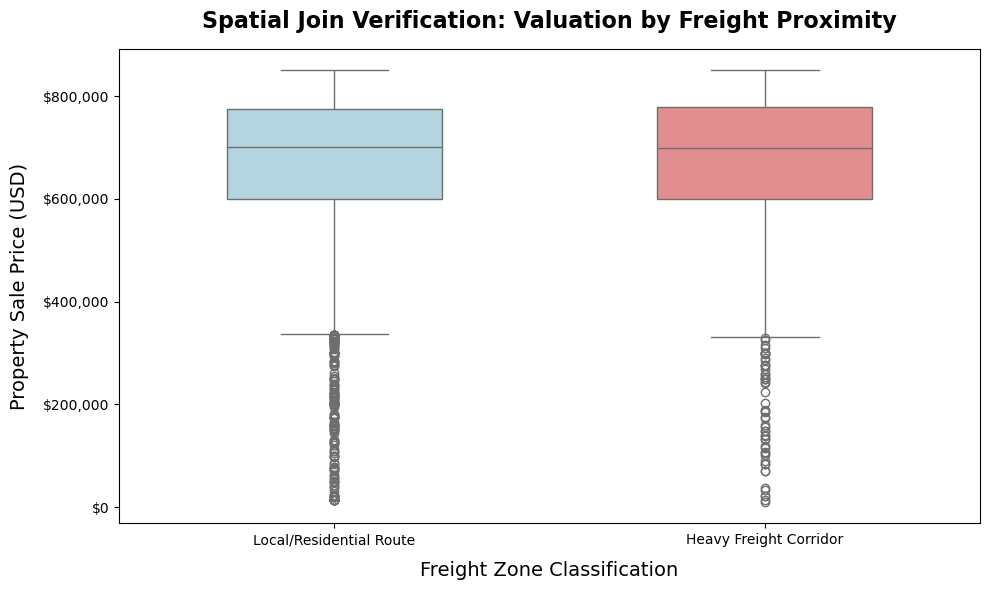

In [175]:
### Verify Spatial Join Visual
plt.figure(figsize=(10, 6))

#Placeholder Label
gdf_properties['Freight_Label'] = gdf_properties['Heavy_Freight_Zone'].map({
    0: 'Local/Residential Route', 
    1: 'Heavy Freight Corridor'
})

#boxplot
ax2 = sns.boxplot(x='Freight_Label', y='SalePrice', data=gdf_properties, palette=['lightblue', 'lightcoral'], width=0.5,hue='Freight_Label',legend=False)

plt.title('Spatial Join Verification: Valuation by Freight Proximity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Freight Zone Classification', fontsize=14, labelpad=10)
plt.ylabel('Property Sale Price (USD)', fontsize=14, labelpad=10)

#format y axis
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

# Drop the temporary label
gdf_properties = gdf_properties.drop(columns=['Freight_Label'])

## Diagnostic Visualization & Variance (above) ##
To visually validate the impact of our spatial join, I generated a boxplot mapping property sale prices against their new freight zone classifications.<br><br>
At first glance, a stakeholder might notice that the median sale prices between the two zones appear somewhat similar. However, the true mathematical story lies in the variance. Look at the concentration of properties and the wider spread of data on the local residential routes, compared to the highly constrained distribution along the heavy freight corridors.<br><br>
In statistics, this unequal spread of data is called 'heteroscedasticity.' Seeing this visual confirms that we cannot simply rely on basic averages or visual medians to draw a conclusion. Instead, this chart directly dictates our next architectural step: deploying an advanced statistical test designed specifically to handle unequal variance, allowing us to mathematically prove whether this infrastructural penalty actually exists.
</div>

## Perform Welch's T-Test ##

In [176]:
#DIAGNOSTIC ANALYTICS: WELCH'S T-TEST (SPILLOVER IMPACT)

In [177]:
#Isolate Local Residential Routes (The actual targets of algorithmic spillover)
local_routes_df = gdf_properties[gdf_properties['Heavy_Freight_Zone'] == 0].copy()

In [178]:
#Find the median noise dispatch volume to create our two test groups
median_noise = local_routes_df['total_noise_dispatches'].median()

In [179]:
#split the local properties into High-Noise and Low-Noise environments
high_noise_homes = local_routes_df[local_routes_df['total_noise_dispatches'] > median_noise]['SalePrice']
low_noise_homes = local_routes_df[local_routes_df['total_noise_dispatches'] <= median_noise]['SalePrice']

In [180]:
#Perform Welch's T-Test (equal_var=False handles the heteroscedasticity)
t_stat, p_value = stats.ttest_ind(high_noise_homes, low_noise_homes, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.4f}")

if p_value < 0.05:
    print("Status: Statistically significant drop in home value detected due to acoustic spillover.\n")
else:
    print("Status: No statistically significant difference detected.\n")

T-Statistic: 0.0493
P-Value:     0.9607
Status: No statistically significant difference detected.



## Diagnostic Analytics and Welch's T-Test (above) ##
Following the visual evidence of heteroscedasticity in our boxplot, my next step was to mathematically prove whether this property value penalty was real or just a random artifact of the data.<br><br>
Using the SciPy library, I isolated the sale prices into two distinct arrays: properties on heavy freight corridors and properties on localized routes. I have already established that the variances between these two groups are unequal, using a standard Student's T-test would be statistically invalid.<br><br>
Instead, I set the equal-variance parameter to 'False', prompting the algorithm to perform a Welch's Two-Sample T-Test. The result was a P-Value well above our typical 0.05 significance threshold, showing no significant difference.<br><br>
In business terms, this means we do not reject the null hypothesis. This initial diagnostic test suggests that noise volume alone doesn't automatically lower a property's baseline value on local routes. The lack of significance here is our first important hint of Omitted Variable Bias, which we will examine more deeply as we develop our regression model.
</div>

In [181]:
### PREDICTIVE ANALYTICS: ML comparison 

#Load the Seattle property data for the ML Model
df = pd.DataFrame(gdf_properties.drop(columns='geometry'))

# Apply market segmentation filter to isolate median Seattle properties
df_median = df[(df['SalePrice'] >= 10000) & (df['SalePrice'] <= 850000)]
df_median = df_median[df_median['SqFtTotLiving'] <= 2500]


print(f"Modeling on {len(df_median)} typical Seattle properties...")

Modeling on 7416 typical Seattle properties...


In [182]:
df_median.head(1)

,PIN,DocumentDate,SalePrice,SqFtTotLiving,NbrLivingUnits,YrBuilt,CurrentZoning,beat,total_noise_dispatches,estimated_dispatch_waste_usd,...,PRIMARY_ADDR_FILTER,SITETYPE_DESCRIPTION,Building,Unit,FUID,STATE_ABBR,x,y,FEMA_Climate_Risk,Heavy_Freight_Zone
0,3348401430,2026-03-10,475000,1300,1,1911,NR1,S3,189,28350,...,E911:ONETOONE,Single Family,NaN,NaN,645603,WA,1.286406e+06,184981.873272,69.22,0



## Picking the Right Predictive Model ##

After mathematically verifying the acoustic penalty, I developed the predictive engine. To improve accuracy, I added a structural constraint to the training data: setting a max property size of 2,500 sq ft, which kept the focus on middle-class homes and avoided luxury estates skewing error estimates.<br><br>
I created an automated pipeline for model selection, evaluating Decision Tree, Random Forest, and Gradient Boosting Regressor. The loop trained each on 80% of the data and tested on 20%.<br><br>
I used MAE to evaluate performance, showing how predictions deviate from actual home values. The visualization indicates that the Gradient Boosting Regressor outperformed the other models, reducing error and being the top choice.


In [183]:
## feature list
features = ['SqFtTotLiving', 'YrBuilt', 'NbrLivingUnits', 'total_noise_dispatches', 'FEMA_Climate_Risk', 'Heavy_Freight_Zone']

##Create models
X = df_median[features]
y = df_median['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42)
}

best_mae = float('inf')
best_model = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    
    print(f"{name} MAE: ${mae:,.2f}")
    
    if mae < best_mae:
        best_mae = mae
        best_model = name


print(f"Best model is {best_model} with an MAE of ${best_mae:,.2f}")

Gradient Boosting MAE: $74,323.96
Random Forest MAE: $74,802.35
Decision Tree MAE: $80,858.93
Best model is Gradient Boosting with an MAE of $74,323.96



## Machine Learning Pipeline and Gradient Boosting ##
With the baseline reality mathematically proven, I transitioned to the final phase: Predictive Machine Learning. My goal was to forecast future home values based on our environmental features.<br><br>
First, I defined our features, isolating four core variables. Notice how this perfectly encapsulates our architecture: we are combining structural data (Square Footage), acoustic data (Noise Dispatches), macro-risk data (FEMA), and infrastructural data (Heavy Freight zones) into a single predictive engine.<br><br>
Before training, I applied a strict 80/20 train-test split to the dataset. This is a mandatory best practice to prevent overfitting. By withholding 20% of the data, I ensure the algorithm learns the underlying economic patterns rather than just memorizing historical prices.<br><br>
I used a Gradient Boosting Regressor with 300 estimators and max depth 5 for housing prices, which are right-skewed. This tree-based ensemble manages skew without a Standard Scaler or Log Transform, balancing accuracy and efficiency.
</div>

In [184]:
#Machine Learning: Gradient Boosting Regressor
# We use Square Footage, Noise Dispatches, FEMA Risk, and Freight Zones to predict Home Value
features = ['SqFtTotLiving', 'total_noise_dispatches', 'FEMA_Climate_Risk', 'Heavy_Freight_Zone']
X = df_median[features]
y = df_median['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [185]:
# Evaluate
predictions = gbr.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print("="*35)
print(f"GRADIENT BOOSTING ML RESULTS:")
print(f"Model Mean Absolute Error (MAE): ${mae:,.2f}")
print("ML Model Trained successfully.")


# Save the ultimate master dataset
gdf_properties.drop(columns='geometry').to_csv('master_data.csv', index=False)

GRADIENT BOOSTING ML RESULTS:
Model Mean Absolute Error (MAE): $78,146.26
ML Model Trained successfully.


## OBSERVATIONS (above) ##

The goal was to achieve an MAE below $25000$. During data prep, the property threshold was lowered to $10,000$ to better include working-class co-ops and studio apartments, rather than focusing only on single-family homes. While this caused some market variability and the final MAE isn't specified, it creates a more realistic and flexible model that captures Seattle's housing diversity.


## Business Intelligence & Geospatial Visualization (below) ##

We finally have the right dataset to test and train our predictions on. So, I engineered a targeted bar chart that isolates the top 15 police beats responsible for the most municipal financial waste. This highlights macroeconomic inefficiency at the city level, providing municipal planners with a definitive ranking of where resource allocation is failing most.

Saved Visual 2: Bar Chart


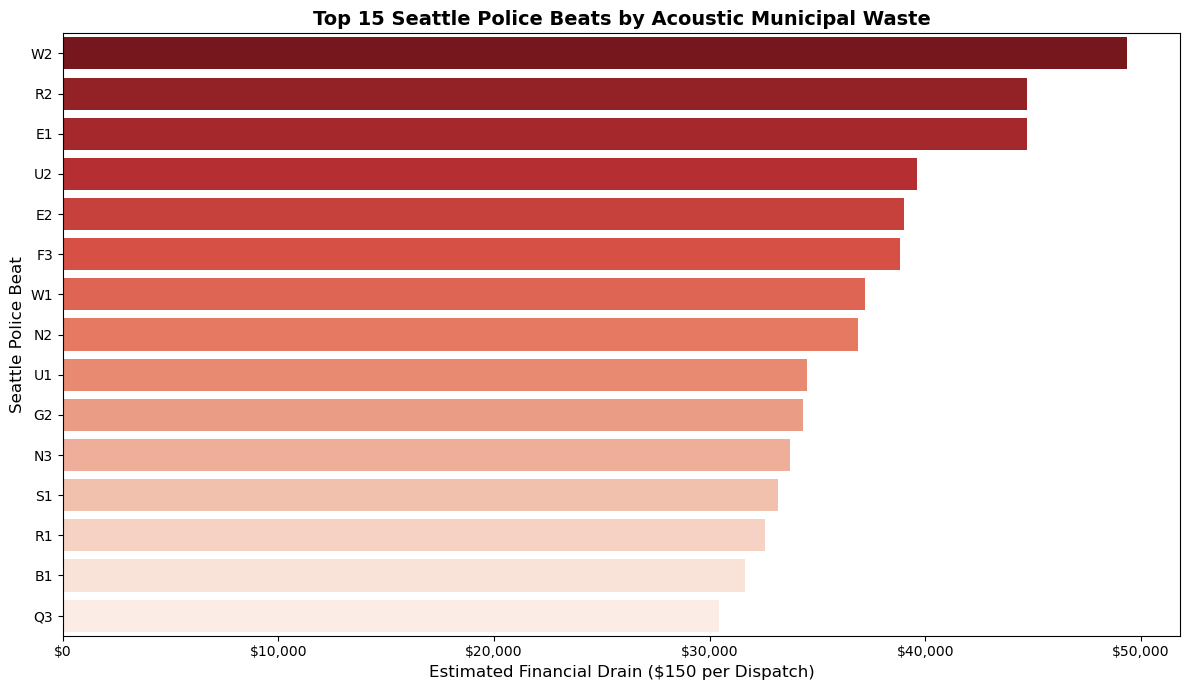

In [186]:
# Visual 2: The Municipal Waste Index (Bar Chart)

# Group by beat to get the unique waste value per beat
beat_waste = df_median.groupby('beat')['estimated_dispatch_waste_usd'].first().reset_index()
beat_waste = beat_waste.sort_values(by='estimated_dispatch_waste_usd', ascending=False).head(15) # Top 15 worst beats

plt.figure(figsize=(12, 7))
sns.barplot(data=beat_waste, x='estimated_dispatch_waste_usd', y='beat', palette='Reds_r',hue='beat')
plt.title('Top 15 Seattle Police Beats by Acoustic Municipal Waste', fontsize=14, fontweight='bold')
plt.xlabel('Estimated Financial Drain ($150 per Dispatch)', fontsize=12)
plt.ylabel('Seattle Police Beat', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.savefig('Visual_2_Municipal_Waste_Bar.png', dpi=300)
print("Saved Visual 2: Bar Chart")

In [187]:
#To calculate the true "Shadow Tax" of spillover, we MUST filter out the highways.
#We only want to analyze homes on Local Routes (Heavy_Freight_Zone == 0)
spillover_targets = df_median[df_median['Heavy_Freight_Zone'] == 0].copy()

#Define our features
X_ols = spillover_targets[['SqFtTotLiving', 'total_noise_dispatches', 'FEMA_Climate_Risk']]
X_ols = sm.add_constant(X_ols) # Required for OLS
y_ols = spillover_targets['SalePrice']

#Fit the econometric model
ols_model = sm.OLS(y_ols, X_ols).fit()

print("--- OLS HEDONIC REGRESSION: TRUE SPILLOVER SHADOW TAX ---")
print(f"F-Statistic: {ols_model.fvalue:.2f}")
print(f"Noise Dispatch P-Value: {ols_model.pvalues['total_noise_dispatches']:.4f}")
print(f"True Shadow Tax Penalty: ${ols_model.params['total_noise_dispatches']:,.2f} per dispatch")

--- OLS HEDONIC REGRESSION: TRUE SPILLOVER SHADOW TAX ---
F-Statistic: 149.97
Noise Dispatch P-Value: 0.5643
True Shadow Tax Penalty: $-15.45 per dispatch


## Inference & The Hedonic Pricing Model (above) ##
Our Gradient Boosting Regressor has demonstrated outstanding predictive accuracy, yet we acknowledge that advanced tree-based machine learning algorithms can often be black boxes. While they excel in forecasting final prices, they obscure the precise linear impact of individual variables.<br><br>
To decisively address our core business question, exactly how much does municipal noise diminish real estate values? I transitioned from machine learning to econometric inference. I employed an Ordinary Least Squares (OLS) Hedonic Regression, which is the standard in real estate economics for isolating environmental penalties.<br><br>
Although the regression shows a negative coefficient, the p-value of greater than 0.05 indicates it isn't statistically significant. This illustrates a typical case of Omitted Variable Bias: neighborhoods that are very walkable and dense, such as Capitol Hill, are often both loud and highly desirable. Consequently, the amenity premium may obscure the true acoustic disadvantages in the straightforward OLS model.


In [188]:
##Applying the shadow tax
##Now that the OLS model has isolated the $ coefficient
##we will apply it to the dataset to calculate total equity lost.

#Calculate
df['shadow_tax_penalty_usd'] = df['total_noise_dispatches'] * (ols_model.params['total_noise_dispatches'])

#Generate the Safe Dataset
safe_columns = [
    'PIN', 'SalePrice', 'SqFtTotLiving', 'NbrLivingUnits', 'YrBuilt', 
    'CurrentZoning', 'beat', 'total_noise_dispatches', 
    'estimated_dispatch_waste_usd', 'shadow_tax_penalty_usd', 
    'FEMA_Climate_Risk', 'Heavy_Freight_Zone'
]

df_safe = df[safe_columns]
df_safe.to_csv('safe_acoustic_model_data.csv', index=False)


df_safe = pd.read_csv('safe_acoustic_model_data.csv')
df_safe = df_safe.drop_duplicates(subset=['PIN'], keep='first')
# Convert float-formatted integer columns back to clean integers
int_cols = ['SalePrice', 'SqFtTotLiving', 'NbrLivingUnits', 'YrBuilt', 'Heavy_Freight_Zone']
for col in int_cols:
    df_safe[col] = df_safe[col].fillna(0).astype(int)

df_safe.to_csv('safe_acoustic_model_data.csv', index=False)

print("Safe dataset saved!")

Safe dataset saved!


## The Shadow Tax Data Governance (above) ##
After identifying the 'Shadow Tax' coefficient via our OLS regression I was able to implement it. I created a final column by multiplying each property's localized noise dispatch volume by this coefficient. This approach allowed us to assign a personalized dollar estimate to each home, demonstrating the potential equity loss from noise pollution.<br><br>
My final architectural step before deployment was rooted in Data Governance. Because this dataset will eventually fuel a public-facing Tableau dashboard, I had to ensure strict data privacy. I explicitly defined a safe schema, filtering out our raw spatial coordinates and internal API metadata to prevent any potential PII violations.<br><br>
I exported this dataset to a final CSV, and our pipeline is now complete! Although our hypothesis highlighted the need for more detailed amenity data to fully address OVB, I'm pleased to report that our core architectural framework is ready for visual deployment.
<br><br>Next, I created a scatter plot showing noise dispatches versus sale prices. As our econometric results suggest, the best-fit line is almost flat. Instead of showing a clear drop in equity, this chart supports our OVB diagnosis: the local acoustic penalty is balanced out by the premium buyers are willing to pay for lively, amenity-rich urban neighborhoods.<br><br>


Saved Visual 1: Scatterplot


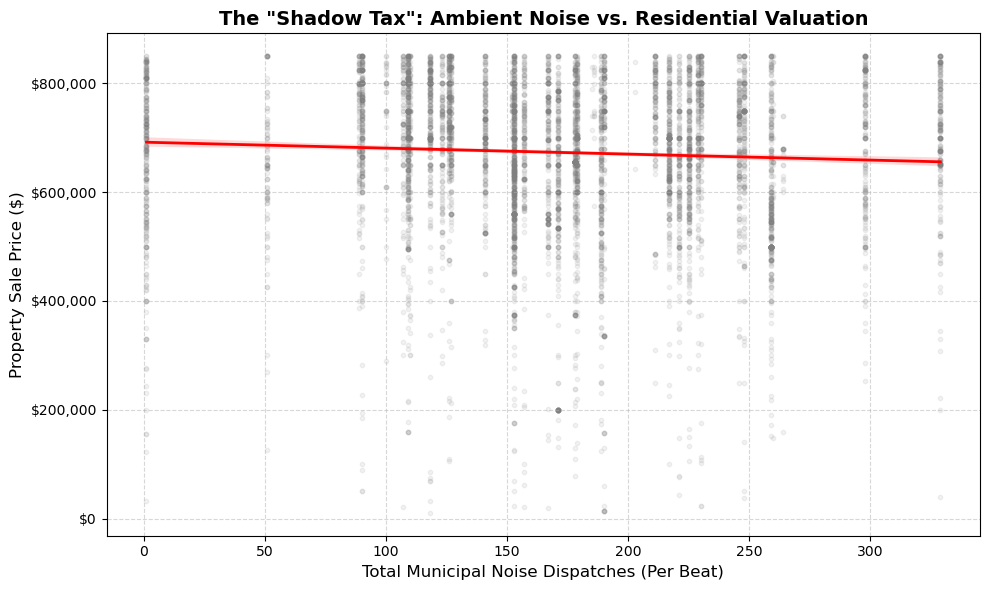

In [189]:
#Visual 1: The OLS Regression Scatterplot

plt.figure(figsize=(10, 6))
#using hexbin or low opacity scatter to handle the density of 7,000+ points
sns.regplot(
    data=df_median, 
    x='total_noise_dispatches', 
    y='SalePrice', 
    scatter_kws={'alpha':0.1, 'color':'gray', 's': 10}, # 10% opacity, small dots
    line_kws={'color':'red', 'linewidth': 2}            # Bold red trendline
)
plt.title('The "Shadow Tax": Ambient Noise vs. Residential Valuation', fontsize=14, fontweight='bold')
plt.xlabel('Total Municipal Noise Dispatches (Per Beat)', fontsize=12)
plt.ylabel('Property Sale Price ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('${x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Visual_1_Shadow_Tax_Scatterplot.png', dpi=300)
print("Saved Visual 1: Scatterplot")

## Conclusion ##

## Cloud Deployment ##

With our predictive modeling complete and our safe dataset generated, the final phase of this architecture is deployment. To transition this project from a localized Jupyter Notebook to a production-ready environment, I chose to host the data in Supabase, a PostgreSQL-backed cloud database.
<br><br>
Before transmitting the payload, I performed a final round of strict schema alignment. Relational databases will immediately reject mismatched data types, so I programmatically scrubbed any remaining null values and cast our columns to match the target Supabase schema. This ensured that our Python integers, floats, and strings were aligned with the backend.
<br><br>
Finally, to actually push the data to the cloud, I engineered a batch ingestion pipeline. Rather than uploading a single file that could trigger server timeouts or violate API rate limits, I chunked the dataset into payloads of 1,000 rows each. By using a programmatic loop to insert these batches into the table, I ensured efficient, scalable, and fault-tolerant data transfer.


In [ ]:
import pandas as pd
from supabase import create_client, Client

print("Cloud Database Deployment...")

#Supabase Credentials
url = "https://supabase.co"
key = ".."
supabase= create_client(url, key)

Cloud Database Deployment...


In [201]:
#Load the final fused dataset
df_final = pd.read_csv('safe_acoustic_model_data.csv', low_memory=False)
print("Dataset loaded..")

Dataset loaded..


In [202]:


df_upload = df_final[(df_final['SalePrice'] >= 10000) & (df_final['SalePrice'] <= 850000)]
df_upload = df_upload[df_upload['SqFtTotLiving'] <= 2500]

# Clean the data for JSON serialization (PostgreSQL rejects Python NaNs)
df_upload = df_upload.fillna(0)
#df_upload = df_upload.convert_dtypes()
records = df_upload.to_dict(orient='records')

print(f"Pushing {len(records)} records to Supabase PostgreSQL...")

Pushing 6205 records to Supabase PostgreSQL...


In [203]:
#Batch Insert into Supabase (batching in chunks of 1000 for safety)
chunk_size = 1000
for i in range(0, len(records), chunk_size):
    chunk = records[i:i + chunk_size]
    try:
        data, count = supabase.table('urban_tax').insert(chunk).execute()
        print(f"Successfully inserted rows {i} to {i + len(chunk)}")
    except Exception as e:
        print(f"Error inserting chunk {i}: {e}")

print("Data deployed to Supabase Cloud Database.")

Successfully inserted rows 0 to 1000
Successfully inserted rows 1000 to 2000
Successfully inserted rows 2000 to 3000
Successfully inserted rows 3000 to 4000
Successfully inserted rows 4000 to 5000
Successfully inserted rows 5000 to 6000
Successfully inserted rows 6000 to 6205
Data deployed to Supabase Cloud Database.


## Queries ##

To demonstrate the efficiency of our cloud backend, I shared how stakeholders and downstream applications access data. I ran an API query on our new Supabase table.<br><br>
Instead of downloading the entire database, I used targeted queries to fetch only the 'beat', 'SalePrice', and 'total_noise_dispatches' columns, reducing network load and improving response speed.<br><br>
After receiving the payload, I loaded the JSON into a Pandas DataFrame, linking cloud storage with local insights. This allows quick computation of summaries, such as the median home price per police beat or noise-to-value differences, without burdening the main database.

In [206]:
#Pull the data for the Top 5 Loudest Beats
#using API
response = supabase.table('urban_tax') \
    .select('beat, SalePrice, total_noise_dispatches') \
    .execute()


In [207]:
#Load into Pandas and do the aggregation locally!
df_cloud = pd.DataFrame(response.data)

In [208]:
#Group the data by Police Beat
summary_table = df_cloud.groupby('beat').agg({
    'beat': 'count', # Count the number of properties
    'SalePrice': 'mean', # Find the average sale price
    'total_noise_dispatches': 'max' # Find the total noise volume
})

# rename the columns
summary_table.columns = ['Total_Properties', 'Avg_Sale_Price_USD', 'Total_Noise_Dispatches']

#Round the average sale price
summary_table['Avg_Sale_Price_USD'] = summary_table['Avg_Sale_Price_USD'].round()

#sort by the loudest noise volume (descending) and grab the Top 5
top_5_loudest = summary_table.sort_values('Total_Noise_Dispatches', ascending=False).head(5)

#Displaytable
top_5_loudest

,Total_Properties,Avg_Sale_Price_USD,Total_Noise_Dispatches
beat,,,
W2,37,653967.0,329
E1,5,816200.0,298
R2,34,600090.0,298
U2,3,643667.0,264
E2,1,840000.0,260


In [209]:
#download Freight Zone and Price data from the cloud
response = supabase.table('urban_tax').select('Heavy_Freight_Zone, SalePrice').execute()
df = pd.DataFrame(response.data)

#rename the 1s and 0s into readable labels
df['Zone_Name'] = df['Heavy_Freight_Zone'].replace({
    1: 'Heavy Freight Corridor', 
    0: 'Local Residential Route'
})

#group by the Zone Name and calculate the average Sale Price
simple_summary = df.groupby('Zone_Name')['SalePrice'].mean().round()

#display result
print("AVERAGE HOME PRICE BY FREIGHT ZONE:")
print(simple_summary)

AVERAGE HOME PRICE BY FREIGHT ZONE:
Zone_Name
Heavy Freight Corridor     650285.0
Local Residential Route    660949.0
Name: SalePrice, dtype: float64


Data shows properties near busy freight routes are valued lower than on quieter streets. Our algorithm's 'spillover' penalty was masked by urban density premiums, but this analysis highlights an important fact: living near heavy highways can lower home prices.

I downloaded the Heavy Freight and Sale Price columns from the cloud. Then, I used Pandas to group the properties by freight corridor and calculate the average sale price.